In [1]:
!pip install -q tensorflow tensorflow-datasets tensorflow-hub scikit-learn matplotlib pandas
!pip install --upgrade protobuf

# **Step 1 — Setup + dataset loading**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
import tensorflow_datasets as tfds
import tensorflow_hub as hub

from sklearn.metrics import classification_report, confusion_matrix

In [3]:
print("TensorFlow version:", tf.__version__)
print("Eager execution:", tf.executing_eagerly())
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
Eager execution: True
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
train_data, validation_data, test_data = tfds.load(
    name="imdb_reviews",
    split=("train[:60%]", "train[60%:]", "test"),
    as_supervised=True
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.KILHAA_1.0.0/imdb_reviews-train.tfrecor…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.KILHAA_1.0.0/imdb_reviews-test.tfrecord…

Generating unsupervised examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.KILHAA_1.0.0/imdb_reviews-unsupervised.…

Dataset imdb_reviews downloaded and prepared to /root/tensorflow_datasets/imdb_reviews/plain_text/1.0.0. Subsequent calls will reuse this data.


In [5]:
print("Train size:", tf.data.experimental.cardinality(train_data).numpy())
print("Validation size:", tf.data.experimental.cardinality(validation_data).numpy())
print("Test size:", tf.data.experimental.cardinality(test_data).numpy())

Train size: 15000
Validation size: 10000
Test size: 25000


In [6]:
for text, label in train_data.take(5):
    print("Review:", text.numpy().decode("utf-8"))
    print("Label:", label.numpy())
    print("-" * 100)

Review: This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning. I am disappointed that there are movies like this, ruining actor's like Christopher Walken's good name. I could barely sit through it.
Label: 0
----------------------------------------------------------------------------------------------------
Review: I have been known to fall asleep during films, but this is usually due to a combination of things including, really tired, being warm and comfortable on the sette a

In [7]:
def get_label_distribution(dataset):
    labels = []
    for _, label in dataset:
        labels.append(label.numpy())
    return pd.Series(labels).value_counts().sort_index()

train_distribution = get_label_distribution(train_data)
validation_distribution = get_label_distribution(validation_data)
test_distribution = get_label_distribution(test_data)

print("Train distribution:")
print(train_distribution)

print("\nValidation distribution:")
print(validation_distribution)

print("\nTest distribution:")
print(test_distribution)

Train distribution:
0    7510
1    7490
Name: count, dtype: int64

Validation distribution:
0    4990
1    5010
Name: count, dtype: int64

Test distribution:
0    12500
1    12500
Name: count, dtype: int64


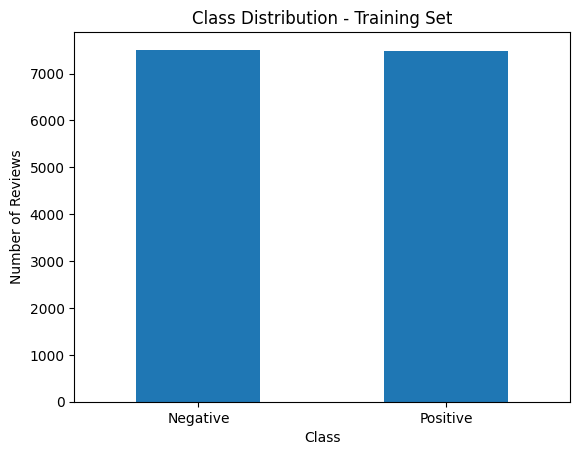

In [8]:
train_distribution.plot(kind="bar")
plt.title("Class Distribution - Training Set")
plt.xlabel("Class")
plt.ylabel("Number of Reviews")
plt.xticks([0, 1], ["Negative", "Positive"], rotation=0)
plt.show()

# **Step 2 — Dataset IMDB exploration**

In [9]:
def dataset_to_lists(dataset):
    texts = []
    labels = []

    for text, label in dataset:
        texts.append(text.numpy().decode("utf-8"))
        labels.append(label.numpy())

    return texts, labels

In [10]:
train_texts, train_labels = dataset_to_lists(train_data)
val_texts, val_labels = dataset_to_lists(validation_data)
test_texts, test_labels = dataset_to_lists(test_data)

In [11]:
print("Train:", len(train_texts), len(train_labels))
print("Validation:", len(val_texts), len(val_labels))
print("Test:", len(test_texts), len(test_labels))

Train: 15000 15000
Validation: 10000 10000
Test: 25000 25000


In [12]:
train_df = pd.DataFrame({
    "review": train_texts,
    "label": train_labels
})

train_df.head()

,review,label
0,This was an absolutely terrible movie. Don't b...,0
1,"I have been known to fall asleep during films,...",0
2,Mann photographs the Alberta Rocky Mountains i...,0
3,This is the kind of film for a snowy Sunday af...,1
4,"As others have mentioned, all the women that g...",1


In [13]:
train_df["sentiment"] = train_df["label"].map({
    0: "negative",
    1: "positive"
})

train_df.head()

,review,label,sentiment
0,This was an absolutely terrible movie. Don't b...,0,negative
1,"I have been known to fall asleep during films,...",0,negative
2,Mann photographs the Alberta Rocky Mountains i...,0,negative
3,This is the kind of film for a snowy Sunday af...,1,positive
4,"As others have mentioned, all the women that g...",1,positive


In [14]:
train_df["sentiment"].value_counts()

,count
sentiment,
negative,7510
positive,7490


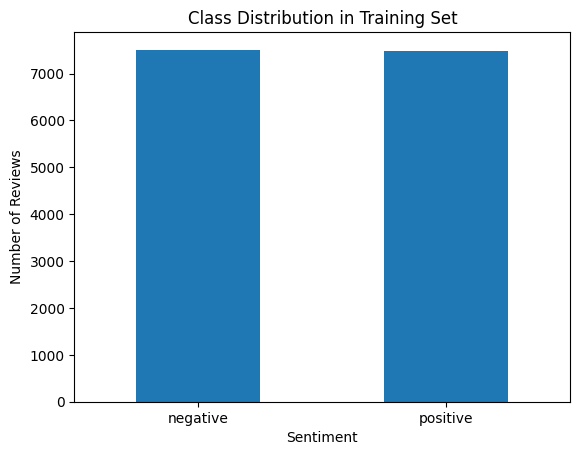

In [15]:
train_df["sentiment"].value_counts().plot(kind="bar")

plt.title("Class Distribution in Training Set")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

In [16]:
train_df["char_length"] = train_df["review"].apply(len)
train_df["word_count"] = train_df["review"].apply(lambda x: len(x.split()))

In [17]:
train_df.head()

,review,label,sentiment,char_length,word_count
0,This was an absolutely terrible movie. Don't b...,0,negative,709,116
1,"I have been known to fall asleep during films,...",0,negative,617,112
2,Mann photographs the Alberta Rocky Mountains i...,0,negative,787,132
3,This is the kind of film for a snowy Sunday af...,1,positive,464,88
4,"As others have mentioned, all the women that g...",1,positive,413,81


In [18]:
train_df[["char_length", "word_count"]].describe()

,char_length,word_count
count,15000.000000,15000.000000
mean,1322.939733,233.550200
std,997.015482,172.986204
min,64.000000,11.000000
25%,703.000000,127.000000
50%,980.000000,174.000000
75%,1614.000000,285.000000
max,13704.000000,2470.000000


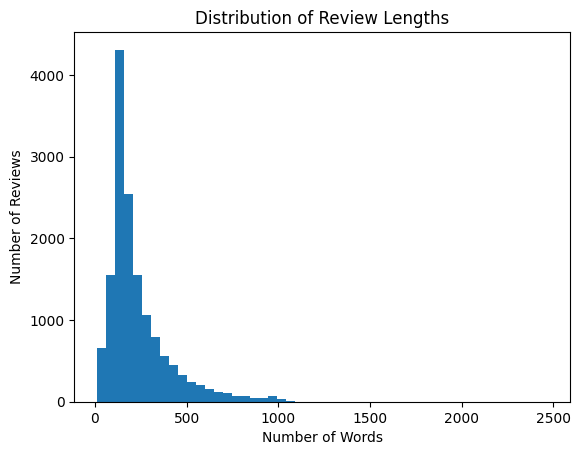

In [19]:
train_df["word_count"].plot(kind="hist", bins=50)

plt.title("Distribution of Review Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")
plt.show()

In [20]:
train_df.groupby("sentiment")["word_count"].describe()

,count,mean,std,min,25%,50%,75%,max
sentiment,,,,,,,,
negative,7510.0,229.492144,164.307793,11.0,128.0,174.0,277.00,1376.0
positive,7490.0,237.619092,181.190904,17.0,125.0,175.0,293.75,2470.0


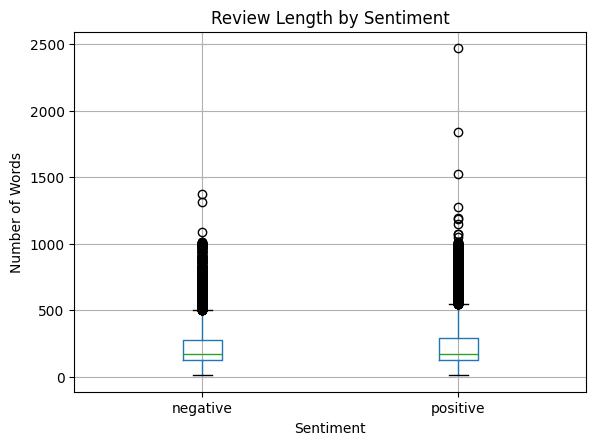

In [21]:
train_df.boxplot(column="word_count", by="sentiment")

plt.title("Review Length by Sentiment")
plt.suptitle("")
plt.xlabel("Sentiment")
plt.ylabel("Number of Words")
plt.show()

In [22]:
negative_reviews = train_df[train_df["label"] == 0]["review"].head(3)

for i, review in enumerate(negative_reviews, 1):
    print(f"Negative review {i}:")
    print(review[:1000])
    print("-" * 100)

Negative review 1:
This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning. I am disappointed that there are movies like this, ruining actor's like Christopher Walken's good name. I could barely sit through it.
----------------------------------------------------------------------------------------------------
Negative review 2:
I have been known to fall asleep during films, but this is usually due to a combination of things including, really tired, being warm and comfortable o

In [23]:
positive_reviews = train_df[train_df["label"] == 1]["review"].head(3)

for i, review in enumerate(positive_reviews, 1):
    print(f"Positive review {i}:")
    print(review[:1000])
    print("-" * 100)

Positive review 1:
This is the kind of film for a snowy Sunday afternoon when the rest of the world can go ahead with its own business as you descend into a big arm-chair and mellow for a couple of hours. Wonderful performances from Cher and Nicolas Cage (as always) gently row the plot along. There are no rapids to cross, no dangerous waters, just a warm and witty paddle through New York life at its best. A family film in every sense and one that deserves the praise it received.
----------------------------------------------------------------------------------------------------
Positive review 2:
As others have mentioned, all the women that go nude in this film are mostly absolutely gorgeous. The plot very ably shows the hypocrisy of the female libido. When men are around they want to be pursued, but when no "men" are around, they become the pursuers of a 14 year old boy. And the boy becomes a man really fast (we should all be so lucky at this age!). He then gets up the courage to purs

In [24]:
train_df.isnull().sum()

,0
review,0
label,0
sentiment,0
char_length,0
word_count,0


In [25]:
empty_reviews = train_df[train_df["review"].str.strip() == ""]

print("Number of empty reviews:", len(empty_reviews))

Number of empty reviews: 0


The IMDB Reviews dataset contains movie reviews labeled as either negative or positive.  
The training set contains 15,000 reviews, the validation set contains 10,000 reviews, and the test set contains 25,000 reviews.

The class distribution is balanced between negative and positive reviews, which makes accuracy a relevant first metric.  

Review lengths vary significantly, which is important for the modeling stage, especially for neural networks and transformer-based models.

# **Step 3 — Baseline : TF-IDF + Logistic Regression**

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [27]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=20000,
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2)
)

In [28]:
X_train_tfidf = tfidf_vectorizer.fit_transform(train_texts)
X_val_tfidf = tfidf_vectorizer.transform(val_texts)
X_test_tfidf = tfidf_vectorizer.transform(test_texts)

In [29]:
# Show the 20 most representative words or expressions of the first review according to TF-IDF
feature_names = tfidf_vectorizer.get_feature_names_out()

review_index = 0

vector = X_train_tfidf[review_index].toarray()[0]

tfidf_df = pd.DataFrame({
    "term": feature_names,
    "tfidf_score": vector
})

tfidf_df = tfidf_df[tfidf_df["tfidf_score"] > 0]
tfidf_df = tfidf_df.sort_values(by="tfidf_score", ascending=False)

tfidf_df.head(20)

,term,tfidf_score
19181,walken,0.404087
3339,christopher walken,0.279183
3334,christopher,0.213125
13359,pathetic,0.201776
11636,michael ironside,0.163854
9420,ironside,0.162241
12074,movie early,0.159357
12252,movie ridiculous,0.156835
11034,lured,0.152576
14834,rebels,0.150743


In [30]:
log_reg_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_reg_model.fit(X_train_tfidf, train_labels)

LogisticRegression(max_iter=1000, random_state=42)

In [31]:
val_predictions = log_reg_model.predict(X_val_tfidf)

val_accuracy = accuracy_score(val_labels, val_predictions)

print("Validation Accuracy:", val_accuracy)

Validation Accuracy: 0.883


In [32]:
print(classification_report(
    val_labels,
    val_predictions,
    target_names=["Negative", "Positive"]
))

              precision    recall  f1-score   support

    Negative       0.89      0.87      0.88      4990
    Positive       0.87      0.90      0.88      5010

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



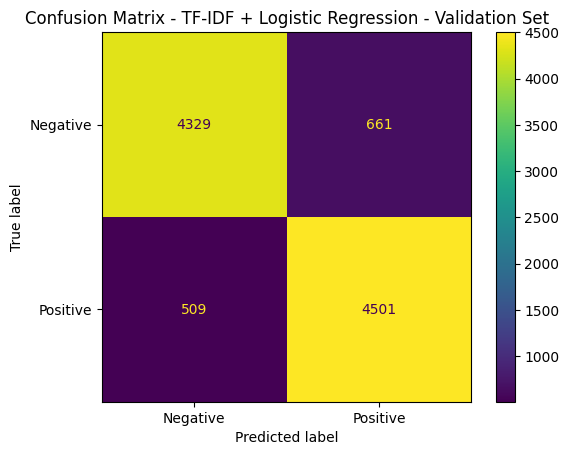

In [33]:
cm_val = confusion_matrix(val_labels, val_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_val,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("Confusion Matrix - TF-IDF + Logistic Regression - Validation Set")
plt.show()

In [34]:
test_predictions = log_reg_model.predict(X_test_tfidf)

test_accuracy = accuracy_score(test_labels, test_predictions)

print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.87628


In [35]:
print(classification_report(
    test_labels,
    test_predictions,
    target_names=["Negative", "Positive"]
))

              precision    recall  f1-score   support

    Negative       0.88      0.87      0.88     12500
    Positive       0.87      0.88      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



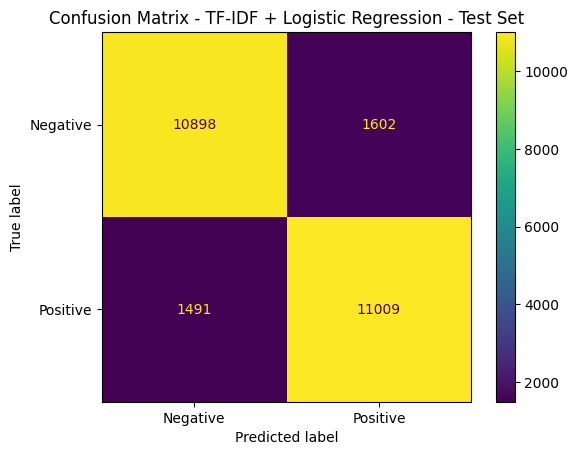

In [36]:
cm_test = confusion_matrix(test_labels, test_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("Confusion Matrix - TF-IDF + Logistic Regression - Test Set")
plt.show()

In [37]:
results = []

results.append({
    "Model": "TF-IDF + Logistic Regression",
    "Validation Accuracy": val_accuracy,
    "Test Accuracy": test_accuracy
})

results_df = pd.DataFrame(results)
results_df

,Model,Validation Accuracy,Test Accuracy
0,TF-IDF + Logistic Regression,0.883,0.87628


The first baseline model uses TF-IDF features combined with Logistic Regression.

This model is simple, fast to train, and provides a strong classical machine learning baseline for sentiment classification.  
Using unigrams and bigrams allows the model to capture individual words as well as short expressions such as "not good" or "very bad".

The performance of this baseline will be compared later with deep learning and transformer-based models.

# **Step 4 — TensorFlow Hub Model**



The first deep learning model uses a pre-trained TensorFlow Hub text embedding layer based on the `gnews-swivel-20dim` model.

This architecture takes raw text reviews as input and directly converts each review into a dense numerical representation of 20 dimensions. The embedding layer is pre-trained, which means it has already learned general semantic relationships between words and short texts from a large external corpus.

The model architecture is composed of three main parts:

1. **TensorFlow Hub Swivel Embedding Layer**  
   This layer receives the raw IMDB review text and transforms it into a 20-dimensional dense vector.  
   This vector represents the semantic information contained in the review.

2. **Dense Hidden Layer**  
   A fully connected layer with 16 neurons and ReLU activation is added after the embedding layer.  
   Its role is to learn useful combinations of the embedding features for sentiment classification.

3. **Output Layer**  
   The final dense layer contains one neuron and outputs a raw score, also called a logit.  
   This score is used to predict whether the review is negative or positive.

Since the output layer does not use a sigmoid activation function, the model is compiled with `BinaryCrossentropy(from_logits=True)`. This tells TensorFlow that the model outputs raw logits instead of probabilities.

Overall, this model can be summarized as:

**Raw text review → Pre-trained Swivel embedding → Dense classification layer → Binary sentiment prediction**

This architecture is simple and efficient, but the embedding dimension is relatively small. Therefore, it may not capture complex linguistic patterns as well as more advanced models such as recurrent neural networks or Transformer-based models.

In [38]:
BATCH_SIZE = 512

train_batches = train_data.shuffle(10000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
validation_batches = validation_data.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_batches = test_data.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [39]:
print("Train batches:", len(train_batches))
print("Validation batches:", len(validation_batches))
print("Test batches:", len(test_batches))


Train batches: 30
Validation batches: 20
Test batches: 49


In [40]:
!pip install -q tf-keras tensorflow-hub



In [41]:
import tensorflow_hub as hub
import tf_keras as keras

In [42]:
hub_layer = hub.KerasLayer(
    "https://tfhub.dev/google/tf2-preview/gnews-swivel-20dim/1",
    input_shape=[],
    dtype=tf.string,
    trainable=True
)

tfhub_model = keras.Sequential([
    hub_layer,
    keras.layers.Dense(16, activation="relu"),
    keras.layers.Dense(1)
])

tfhub_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 keras_layer (KerasLayer)    (None, 20)                400020    
                                                                 
 dense (Dense)               (None, 16)                336       
                                                                 
 dense_1 (Dense)             (None, 1)                 17        
                                                                 
Total params: 400373 (1.53 MB)
Trainable params: 400373 (1.53 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [43]:
tfhub_model.compile(
    optimizer="adam",
    loss=keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

In [44]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_tfhub = tfhub_model.fit(
    train_batches,
    validation_data=validation_batches,
    epochs=20,
    callbacks=[early_stopping]
)

Epoch 1/20
30/30 [==============================] - 8s 161ms/step - loss: 0.8326 - accuracy: 0.5515 - val_loss: 0.6756 - val_accuracy: 0.5695
Epoch 2/20
30/30 [==============================] - 5s 167ms/step - loss: 0.6479 - accuracy: 0.5980 - val_loss: 0.6304 - val_accuracy: 0.6182
Epoch 3/20
30/30 [==============================] - 4s 143ms/step - loss: 0.6186 - accuracy: 0.6261 - val_loss: 0.6104 - val_accuracy: 0.6304
Epoch 4/20
30/30 [==============================] - 5s 152ms/step - loss: 0.5975 - accuracy: 0.6489 - val_loss: 0.5916 - val_accuracy: 0.6599
Epoch 5/20
30/30 [==============================] - 4s 122ms/step - loss: 0.5754 - accuracy: 0.6717 - val_loss: 0.5710 - val_accuracy: 0.6771
Epoch 6/20
30/30 [==============================] - 5s 161ms/step - loss: 0.5513 - accuracy: 0.6947 - val_loss: 0.5491 - val_accuracy: 0.7005
Epoch 7/20
30/30 [==============================] - 5s 149ms/step - loss: 0.5256 - accuracy: 0.7153 - val_loss: 0.5266 - val_accuracy: 0.7299
Epoch 

In [45]:
history_df = pd.DataFrame(history_tfhub.history)
history_df

,loss,accuracy,val_loss,val_accuracy
0,0.832613,0.551533,0.675649,0.5695
1,0.647866,0.598000,0.630375,0.6182
2,0.618642,0.626133,0.610368,0.6304
3,0.597485,0.648867,0.591640,0.6599
4,0.575390,0.671733,0.570994,0.6771
5,0.551297,0.694667,0.549097,0.7005
6,0.525623,0.715333,0.526623,0.7299
7,0.496590,0.744267,0.500931,0.7466
8,0.465621,0.765133,0.476756,0.7618
9,0.435945,0.787667,0.453798,0.7739


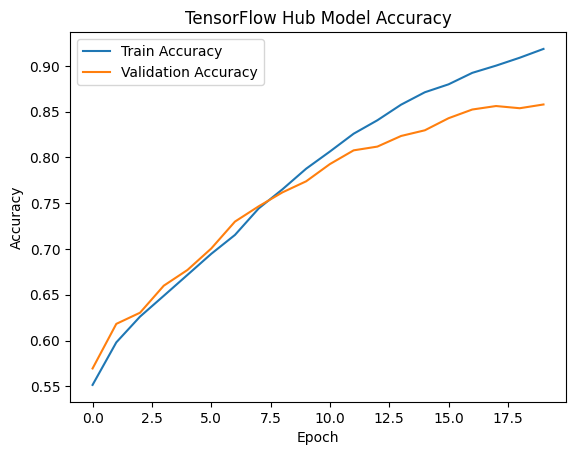

In [46]:
plt.plot(history_df["accuracy"], label="Train Accuracy")
plt.plot(history_df["val_accuracy"], label="Validation Accuracy")

plt.title("TensorFlow Hub Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

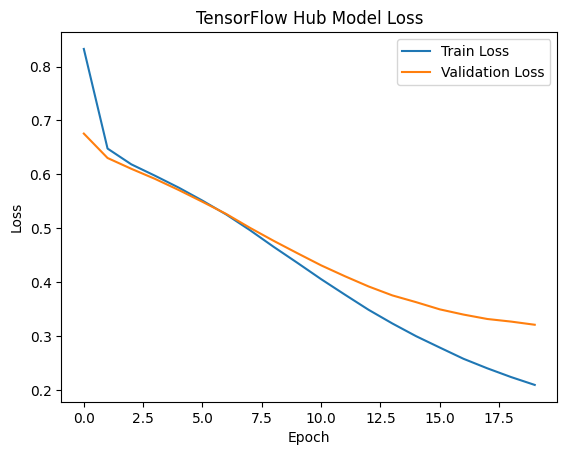

In [47]:
plt.plot(history_df["loss"], label="Train Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")

plt.title("TensorFlow Hub Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [48]:
tfhub_val_loss, tfhub_val_accuracy = tfhub_model.evaluate(validation_batches)
tfhub_test_loss, tfhub_test_accuracy = tfhub_model.evaluate(test_batches)

print("Validation Accuracy:", tfhub_val_accuracy)
print("Test Accuracy:", tfhub_test_accuracy)

49/49 [==============================] - 1s 19ms/step - loss: 0.3348 - accuracy: 0.8456
Validation Accuracy: 0.8578000068664551
Test Accuracy: 0.8456000089645386


In [49]:
results.append({
    "Model": "TensorFlow Hub + Dense",
    "Validation Accuracy": tfhub_val_accuracy,
    "Test Accuracy": tfhub_test_accuracy
})

results_df = pd.DataFrame(results)
results_df

,Model,Validation Accuracy,Test Accuracy
0,TF-IDF + Logistic Regression,0.8830,0.87628
1,TensorFlow Hub + Dense,0.8578,0.84560


In [50]:
tfhub_logits = tfhub_model.predict(test_batches)
tfhub_probs = tf.sigmoid(tfhub_logits).numpy().flatten()
tfhub_predictions = (tfhub_probs >= 0.5).astype(int)

49/49 [==============================] - 1s 18ms/step


In [51]:
test_labels_batched = np.concatenate([
    labels.numpy() for _, labels in test_batches
])

In [52]:
print(classification_report(
    test_labels_batched,
    tfhub_predictions,
    target_names=["Negative", "Positive"]
))

              precision    recall  f1-score   support

    Negative       0.84      0.87      0.86     12500
    Positive       0.87      0.84      0.85     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000



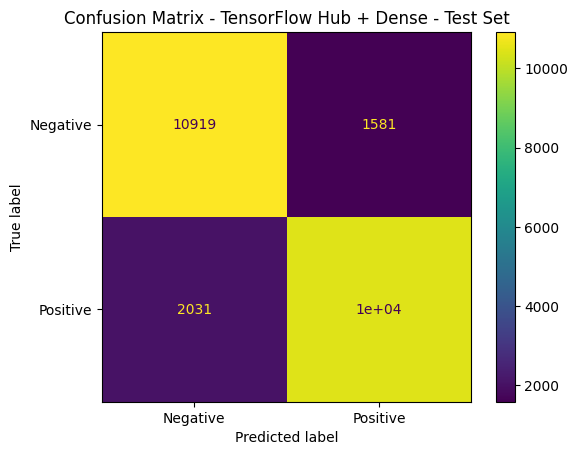

In [53]:
cm_tfhub = confusion_matrix(test_labels_batched, tfhub_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tfhub,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("Confusion Matrix - TensorFlow Hub + Dense - Test Set")
plt.show()

The TF-IDF + Logistic Regression baseline outperformed the TensorFlow Hub dense model.  
This shows that a well-designed classical machine learning baseline can be highly competitive for sentiment classification tasks.

The TensorFlow Hub model achieved lower validation and test accuracy, probably because the pre-trained embedding used is relatively small and the architecture is simple.

# **Step 4 bis — TensorFlow Hub bis**

The second TensorFlow Hub model uses the `Universal Sentence Encoder` from TensorFlow Hub.

Unlike the `gnews-swivel-20dim` model, which produces a small 20-dimensional text embedding, the Universal Sentence Encoder generates richer sentence-level embeddings. It is designed to encode complete sentences, paragraphs, and short texts into dense numerical vectors that capture semantic meaning.

The model architecture is composed of three main parts:

1. **Universal Sentence Encoder Layer**  
   This layer receives the raw IMDB review text and converts each review into a dense semantic vector.  
   The goal of this embedding is to represent the overall meaning of the review rather than only individual word-level information.

2. **Dense Hidden Layers**  
   After the embedding layer, fully connected dense layers are added to learn task-specific patterns for sentiment classification.  
   These layers use ReLU activation functions to model non-linear relationships between the sentence embedding features and the sentiment label.

3. **Dropout Layers**  
   Dropout layers are added between dense layers to reduce overfitting.  
   During training, dropout randomly disables a fraction of neurons, which encourages the model to learn more robust representations.

4. **Output Layer**  
   The final dense layer contains one neuron with a sigmoid activation function.  
   It outputs a probability between 0 and 1, where values close to 0 indicate a negative review and values close to 1 indicate a positive review.

Since the output layer uses a sigmoid activation function, the model is compiled with `binary_crossentropy`. This loss function is appropriate for binary classification when the model outputs probabilities.

Overall, this model can be summarized as:

**Raw text review → Universal Sentence Encoder embedding → Dense layers with dropout → Binary sentiment probability**

This architecture is more semantically expressive than the Swivel-based TensorFlow Hub model because it uses sentence-level embeddings.

In [54]:
use_layer = hub.KerasLayer(
    "https://tfhub.dev/google/universal-sentence-encoder/4",
    input_shape=[],
    dtype=tf.string,
    trainable=False
)

tfhub_improved_model = keras.Sequential([
    use_layer,
    keras.layers.Dense(256, activation="relu"),
    keras.layers.Dropout(0.4),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation="sigmoid")
])

tfhub_improved_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 keras_layer_1 (KerasLayer)  (None, 512)               256797824 
                                                                 
 dense_2 (Dense)             (None, 256)               131328    
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_3 (Dense)             (None, 128)               32896     
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 dense_4 (Dense)             (None, 1)                 129       
                                                                 
Total params: 256962177 (980.23 MB)
Trainable params: 

In [55]:
tfhub_improved_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [56]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

In [57]:
history_tfhub_improved = tfhub_improved_model.fit(
    train_batches,
    validation_data=validation_batches,
    epochs=20,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/20
30/30 [==============================] - 30s 781ms/step - loss: 0.6853 - accuracy: 0.6026 - val_loss: 0.6740 - val_accuracy: 0.7489 - lr: 1.0000e-04
Epoch 2/20
30/30 [==============================] - 22s 737ms/step - loss: 0.6627 - accuracy: 0.7223 - val_loss: 0.6407 - val_accuracy: 0.7899 - lr: 1.0000e-04
Epoch 3/20
30/30 [==============================] - 22s 751ms/step - loss: 0.6221 - accuracy: 0.7711 - val_loss: 0.5816 - val_accuracy: 0.8102 - lr: 1.0000e-04
Epoch 4/20
30/30 [==============================] - 22s 750ms/step - loss: 0.5584 - accuracy: 0.7972 - val_loss: 0.5062 - val_accuracy: 0.8214 - lr: 1.0000e-04
Epoch 5/20
30/30 [==============================] - 22s 753ms/step - loss: 0.4886 - accuracy: 0.8127 - val_loss: 0.4415 - val_accuracy: 0.8291 - lr: 1.0000e-04
Epoch 6/20
30/30 [==============================] - 22s 728ms/step - loss: 0.4336 - accuracy: 0.8246 - val_loss: 0.3989 - val_accuracy: 0.8355 - lr: 1.0000e-04
Epoch 7/20
30/30 [======================

In [58]:
history_tfhub_improved_df = pd.DataFrame(history_tfhub_improved.history)
history_tfhub_improved_df

,loss,accuracy,val_loss,val_accuracy,lr
0,0.685265,0.602600,0.673996,0.7489,0.0001
1,0.662744,0.722267,0.640704,0.7899,0.0001
2,0.622144,0.771133,0.581627,0.8102,0.0001
3,0.558366,0.797200,0.506186,0.8214,0.0001
4,0.488641,0.812667,0.441488,0.8291,0.0001
5,0.433633,0.824600,0.398913,0.8355,0.0001
6,0.399563,0.832800,0.374381,0.8410,0.0001
7,0.376900,0.842467,0.359504,0.8449,0.0001
8,0.363145,0.843933,0.350923,0.8478,0.0001
9,0.353697,0.847000,0.344932,0.8498,0.0001


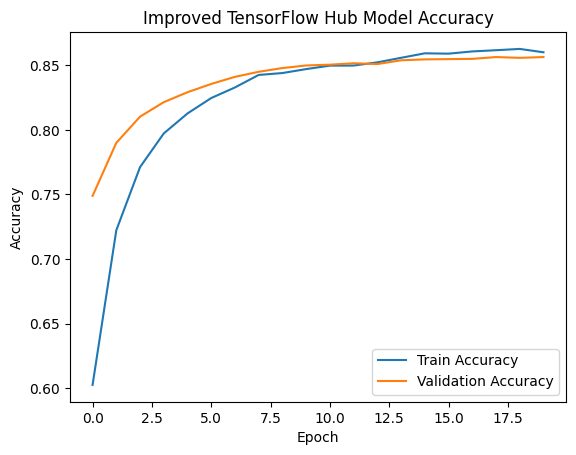

In [59]:
plt.plot(history_tfhub_improved_df["accuracy"], label="Train Accuracy")
plt.plot(history_tfhub_improved_df["val_accuracy"], label="Validation Accuracy")

plt.title("Improved TensorFlow Hub Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

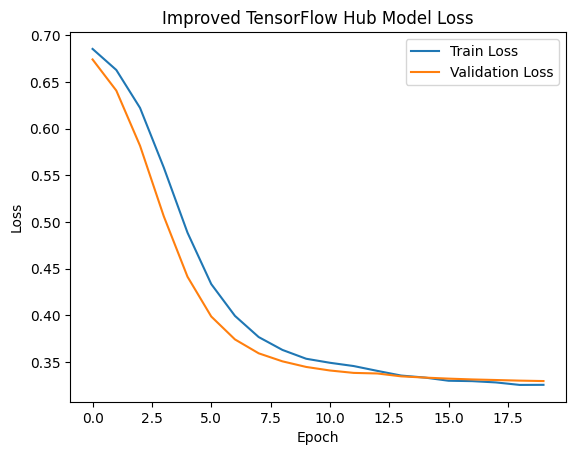

In [60]:
plt.plot(history_tfhub_improved_df["loss"], label="Train Loss")
plt.plot(history_tfhub_improved_df["val_loss"], label="Validation Loss")

plt.title("Improved TensorFlow Hub Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [61]:
tfhub_improved_val_loss, tfhub_improved_val_accuracy = tfhub_improved_model.evaluate(
    validation_batches
)

tfhub_improved_test_loss, tfhub_improved_test_accuracy = tfhub_improved_model.evaluate(
    test_batches
)

print("Validation Accuracy:", tfhub_improved_val_accuracy)
print("Test Accuracy:", tfhub_improved_test_accuracy)

49/49 [==============================] - 20s 414ms/step - loss: 0.3253 - accuracy: 0.8575
Validation Accuracy: 0.8562999963760376
Test Accuracy: 0.8575199842453003


In [62]:
results.append({
    "Model": "TensorFlow Hub USE + Dense",
    "Validation Accuracy": tfhub_improved_val_accuracy,
    "Test Accuracy": tfhub_improved_test_accuracy
})

results_df = pd.DataFrame(results)
results_df

,Model,Validation Accuracy,Test Accuracy
0,TF-IDF + Logistic Regression,0.8830,0.87628
1,TensorFlow Hub + Dense,0.8578,0.84560
2,TensorFlow Hub USE + Dense,0.8563,0.85752


In [63]:
tfhub_improved_probs = tfhub_improved_model.predict(test_batches).flatten()
tfhub_improved_predictions = (tfhub_improved_probs >= 0.5).astype(int)

49/49 [==============================] - 21s 415ms/step


In [64]:
test_labels_batched = np.concatenate([
    labels.numpy() for _, labels in test_batches
])

In [65]:
print(classification_report(
    test_labels_batched,
    tfhub_improved_predictions,
    target_names=["Negative", "Positive"]
))

              precision    recall  f1-score   support

    Negative       0.85      0.86      0.86     12500
    Positive       0.86      0.85      0.86     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000



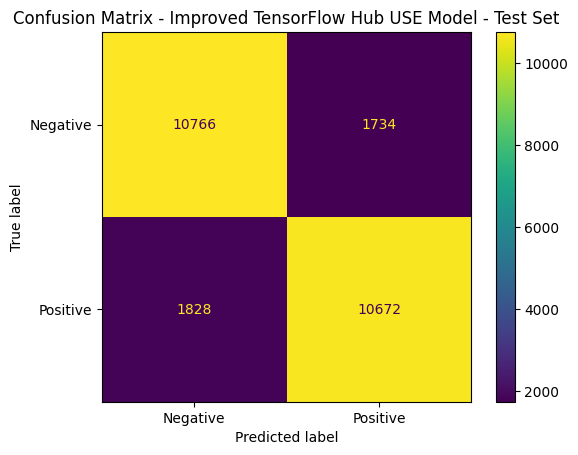

In [66]:
cm_tfhub_improved = confusion_matrix(
    test_labels_batched,
    tfhub_improved_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tfhub_improved,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("Confusion Matrix - Improved TensorFlow Hub USE Model - Test Set")
plt.show()

The Universal Sentence Encoder model did not improve performance compared to the TF-IDF baseline.
Although USE provides richer semantic sentence embeddings, the frozen representation may not be sufficiently adapted to sentiment classification.

The TF-IDF + Logistic Regression baseline remains the best-performing model so far, showing that classical machine learning approaches can be very competitive on sentiment classification tasks.

# **Step 4 ter — TensorFlow Hub NNLM 128D**

The third TensorFlow Hub model uses the `nnlm-en-dim128` embedding model.

This model converts each raw text review into a dense numerical vector of 128 dimensions. Unlike TF-IDF, which creates sparse vectors based on word frequency, NNLM produces dense embeddings that capture semantic and lexical relationships learned from a large text corpus.

The architecture is composed of the following parts:

1. **NNLM 128D Embedding Layer**  
   The TensorFlow Hub layer receives the raw IMDB review text and converts it into a 128-dimensional dense vector.  
   This vector summarizes the review in a numerical form that can be used by the neural network.

2. **Dense Hidden Layers**  
   After the embedding layer, dense layers are added to learn task-specific patterns related to sentiment classification.  
   These layers transform the 128-dimensional embedding into more useful internal representations for predicting whether the review is positive or negative.

3. **Dropout Layers**  


4. **Output Layer**  
   The final dense layer contains one neuron with a sigmoid activation function.  

Overall, this model can be summarized as:

**Raw text review → NNLM 128D embedding → Dense layers with dropout → Binary sentiment probability**

In this experiment, the NNLM layer was set as trainable, which means its embedding weights could be updated during training to better adapt to the IMDB sentiment classification task.

In [67]:
nnlm_layer = hub.KerasLayer(
    "https://tfhub.dev/google/nnlm-en-dim128/2",
    input_shape=[],
    dtype=tf.string,
    trainable=True
)

In [68]:
tfhub_nnlm_model = keras.Sequential([
    nnlm_layer,
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.4),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation="sigmoid")
])

tfhub_nnlm_model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 keras_layer_2 (KerasLayer)  (None, 128)               124642688 
                                                                 
 dense_5 (Dense)             (None, 128)               16512     
                                                                 
 dropout_2 (Dropout)         (None, 128)               0         
                                                                 
 dense_6 (Dense)             (None, 64)                8256      
                                                                 
 dropout_3 (Dropout)         (None, 64)                0         
                                                                 
 dense_7 (Dense)             (None, 1)                 65        
                                                                 
Total params: 124667521 (475.57 MB)
Trainable params: 

In [69]:
tfhub_nnlm_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [70]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

history_tfhub_nnlm = tfhub_nnlm_model.fit(
    train_batches,
    validation_data=validation_batches,
    epochs=20,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/20
30/30 [==============================] - 7s 200ms/step - loss: 0.6979 - accuracy: 0.5178 - val_loss: 0.6753 - val_accuracy: 0.6516 - lr: 1.0000e-04
Epoch 2/20
30/30 [==============================] - 5s 186ms/step - loss: 0.6767 - accuracy: 0.5828 - val_loss: 0.6539 - val_accuracy: 0.7021 - lr: 1.0000e-04
Epoch 3/20
30/30 [==============================] - 5s 176ms/step - loss: 0.6529 - accuracy: 0.6371 - val_loss: 0.6294 - val_accuracy: 0.7266 - lr: 1.0000e-04
Epoch 4/20
30/30 [==============================] - 5s 175ms/step - loss: 0.6262 - accuracy: 0.6832 - val_loss: 0.5978 - val_accuracy: 0.7440 - lr: 1.0000e-04
Epoch 5/20
30/30 [==============================] - 5s 165ms/step - loss: 0.5915 - accuracy: 0.7201 - val_loss: 0.5577 - val_accuracy: 0.7667 - lr: 1.0000e-04
Epoch 6/20
30/30 [==============================] - 5s 170ms/step - loss: 0.5497 - accuracy: 0.7599 - val_loss: 0.5119 - val_accuracy: 0.7885 - lr: 1.0000e-04
Epoch 7/20
30/30 [============================

In [71]:
tfhub_nnlm_val_loss, tfhub_nnlm_val_accuracy = tfhub_nnlm_model.evaluate(validation_batches)
tfhub_nnlm_test_loss, tfhub_nnlm_test_accuracy = tfhub_nnlm_model.evaluate(test_batches)

print("Validation Accuracy:", tfhub_nnlm_val_accuracy)
print("Test Accuracy:", tfhub_nnlm_test_accuracy)

49/49 [==============================] - 1s 15ms/step - loss: 0.3331 - accuracy: 0.8599
Validation Accuracy: 0.873199999332428
Test Accuracy: 0.8599200248718262


In [72]:
results.append({
    "Model": "TensorFlow Hub NNLM 128D + Dense",
    "Validation Accuracy": tfhub_nnlm_val_accuracy,
    "Test Accuracy": tfhub_nnlm_test_accuracy
})

results_df = pd.DataFrame(results)
results_df

,Model,Validation Accuracy,Test Accuracy
0,TF-IDF + Logistic Regression,0.8830,0.87628
1,TensorFlow Hub + Dense,0.8578,0.84560
2,TensorFlow Hub USE + Dense,0.8563,0.85752
3,TensorFlow Hub NNLM 128D + Dense,0.8732,0.85992


Several TensorFlow Hub-based models were evaluated, including a simple dense model, Universal Sentence Encoder, and NNLM 128D embeddings.

None of these models outperformed the TF-IDF + Logistic Regression baseline.  
The best TensorFlow Hub variant was the NNLM 128D model, but its test accuracy remained below the classical machine learning baseline.

This result highlights that classical NLP methods such as TF-IDF combined with Logistic Regression can remain highly competitive for sentiment classification, especially on structured benchmark datasets like IMDB reviews.

# **Step 5 — BiLSTM Model**

In [73]:
train_texts_array = np.array(train_texts)
val_texts_array = np.array(val_texts)
test_texts_array = np.array(test_texts)

train_labels_array = np.array(train_labels)
val_labels_array = np.array(val_labels)
test_labels_array = np.array(test_labels)

In [74]:
from tensorflow.keras.layers import TextVectorization
from tensorflow.keras import layers, models

Before training the BiLSTM model, the raw text reviews must be converted into numerical sequences. This is done using the `TextVectorization` layer.

The vectorization layer first learns a vocabulary from the training reviews using the `adapt()` method. In this experiment, the vocabulary size is limited to the most frequent words using `MAX_TOKENS`. Each word in the vocabulary is assigned a unique integer index.

With `output_mode="int"`, each review is transformed into a sequence of integer token IDs. Unlike TF-IDF, this representation preserves the order of words, which is important for recurrent neural networks such as LSTM and BiLSTM.

The parameter `output_sequence_length` ensures that all reviews have the same length. Shorter reviews are padded with zeros, while longer reviews are truncated. This allows the model to process the data in fixed-size batches.

The vectorized sequence is then passed to an Embedding layer, which transforms each integer token into a dense vector representation. These embeddings are learned during training and are then processed by the BiLSTM layer to capture contextual information from both directions of the text.

The complete preprocessing flow is:

**Raw text review → TextVectorization → Integer token sequence → Embedding layer → BiLSTM**

In [75]:
MAX_TOKENS = 20000
SEQUENCE_LENGTH = 300

vectorizer = TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode="int",
    output_sequence_length=SEQUENCE_LENGTH
)

vectorizer.adapt(train_texts_array)

In [76]:
EMBEDDING_DIM = 128

bilstm_model = models.Sequential([
    layers.Input(shape=(1,), dtype=tf.string),
    vectorizer,
    layers.Embedding(
        input_dim=MAX_TOKENS,
        output_dim=EMBEDDING_DIM,
        mask_zero=True
    ),
    layers.Bidirectional(layers.LSTM(64)),
    layers.Dropout(0.5),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

bilstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 300)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 300, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,667,137 (10.17 MB)

 Trainable params: 2,667,137 (10.17 MB)

 Non-trainable params: 0 (0.00 B)

In [77]:
bilstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [78]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# Create TensorFlow Datasets for training and validation
BATCH_SIZE_FIT = 64
train_dataset_bilstm = tf.data.Dataset.from_tensor_slices((train_texts_array, train_labels_array)).batch(BATCH_SIZE_FIT).prefetch(tf.data.AUTOTUNE)
validation_dataset_bilstm = tf.data.Dataset.from_tensor_slices((val_texts_array, val_labels_array)).batch(BATCH_SIZE_FIT).prefetch(tf.data.AUTOTUNE)

history_bilstm = bilstm_model.fit(
    train_dataset_bilstm,
    validation_data=validation_dataset_bilstm,
    epochs=20,
    callbacks=[early_stopping]
)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 12s 40ms/step - accuracy: 0.7585 - loss: 0.4807 - val_accuracy: 0.8577 - val_loss: 0.3556
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - accuracy: 0.9126 - loss: 0.2303 - val_accuracy: 0.8568 - val_loss: 0.3536
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - accuracy: 0.9474 - loss: 0.1471 - val_accuracy: 0.8547 - val_loss: 0.4606
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - accuracy: 0.9671 - loss: 0.0970 - val_accuracy: 0.8063 - val_loss: 0.9658
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - accuracy: 0.9613 - loss: 0.1092 - val_accuracy: 0.8019 - val_loss: 0.7407


In [79]:
val_dataset_bilstm_eval = tf.data.Dataset.from_tensor_slices((val_texts_array, val_labels_array)).batch(BATCH_SIZE_FIT).prefetch(tf.data.AUTOTUNE)
test_dataset_bilstm_eval = tf.data.Dataset.from_tensor_slices((test_texts_array, test_labels_array)).batch(BATCH_SIZE_FIT).prefetch(tf.data.AUTOTUNE)

bilstm_val_loss, bilstm_val_accuracy = bilstm_model.evaluate(
    val_dataset_bilstm_eval
)

bilstm_test_loss, bilstm_test_accuracy = bilstm_model.evaluate(
    test_dataset_bilstm_eval
)

print("Validation Accuracy:", bilstm_val_accuracy)
print("Test Accuracy:", bilstm_test_accuracy)

157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8568 - loss: 0.3536
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8426 - loss: 0.3835
Validation Accuracy: 0.8568000197410583
Test Accuracy: 0.8426399827003479


In [80]:
results.append({
    "Model": "BiLSTM",
    "Validation Accuracy": bilstm_val_accuracy,
    "Test Accuracy": bilstm_test_accuracy
})

results_df = pd.DataFrame(results)
results_df

,Model,Validation Accuracy,Test Accuracy
0,TF-IDF + Logistic Regression,0.8830,0.87628
1,TensorFlow Hub + Dense,0.8578,0.84560
2,TensorFlow Hub USE + Dense,0.8563,0.85752
3,TensorFlow Hub NNLM 128D + Dense,0.8732,0.85992
4,BiLSTM,0.8568,0.84264


In [81]:
example_review = test_texts_array[0]

print(example_review[:1000])

There are films that make careers. For George Romero, it was NIGHT OF THE LIVING DEAD; for Kevin Smith, CLERKS; for Robert Rodriguez, EL MARIACHI. Add to that list Onur Tukel's absolutely amazing DING-A-LING-LESS. Flawless film-making, and as assured and as professional as any of the aforementioned movies. I haven't laughed this hard since I saw THE FULL MONTY. (And, even then, I don't think I laughed quite this hard... So to speak.) Tukel's talent is considerable: DING-A-LING-LESS is so chock full of double entendres that one would have to sit down with a copy of this script and do a line-by-line examination of it to fully appreciate the, uh, breadth and width of it. Every shot is beautifully composed (a clear sign of a sure-handed director), and the performances all around are solid (there's none of the over-the-top scenery chewing one might've expected from a film like this). DING-A-LING-LESS is a film whose time has come.


In [82]:
token_ids = vectorizer(tf.constant([example_review]))

print("Token IDs shape:", token_ids.shape)
print(token_ids[0][:30].numpy())

Token IDs shape: (1, 300)
[   48    25    97    12    94  5114    16   707  4250     9    14   301
     5     2   578   355    16  1808  1282 13701    16   655  7610  6248
     1   720     6    12  1126     1]


In [83]:
vocab = vectorizer.get_vocabulary()

tokens = [vocab[token_id] for token_id in token_ids[0].numpy()]

print(tokens[:50])

[np.str_('there'), np.str_('are'), np.str_('films'), np.str_('that'), np.str_('make'), np.str_('careers'), np.str_('for'), np.str_('george'), np.str_('romero'), np.str_('it'), np.str_('was'), np.str_('night'), np.str_('of'), np.str_('the'), np.str_('living'), np.str_('dead'), np.str_('for'), np.str_('kevin'), np.str_('smith'), np.str_('clerks'), np.str_('for'), np.str_('robert'), np.str_('rodriguez'), np.str_('el'), '[UNK]', np.str_('add'), np.str_('to'), np.str_('that'), np.str_('list'), '[UNK]', '[UNK]', np.str_('absolutely'), np.str_('amazing'), '[UNK]', np.str_('flawless'), np.str_('filmmaking'), np.str_('and'), np.str_('as'), np.str_('assured'), np.str_('and'), np.str_('as'), np.str_('professional'), np.str_('as'), np.str_('any'), np.str_('of'), np.str_('the'), np.str_('aforementioned'), np.str_('movies'), np.str_('i'), np.str_('havent')]


In [84]:
for i, layer in enumerate(bilstm_model.layers):
    print(i, layer.name, type(layer))

0 text_vectorization <class 'keras.src.layers.preprocessing.text_vectorization.TextVectorization'>
1 embedding <class 'keras.src.layers.core.embedding.Embedding'>
2 bidirectional <class 'keras.src.layers.rnn.bidirectional.Bidirectional'>
3 dropout <class 'keras.src.layers.regularization.dropout.Dropout'>
4 dense <class 'keras.src.layers.core.dense.Dense'>
5 dropout_1 <class 'keras.src.layers.regularization.dropout.Dropout'>
6 dense_1 <class 'keras.src.layers.core.dense.Dense'>


In [85]:
embedding_layer = bilstm_model.layers[1]

In [86]:
embedding_output = embedding_layer(token_ids)

print("Embedding output shape:", embedding_output.shape)

Embedding output shape: (1, 300, 128)


In [87]:
embedding_matrix = embedding_output[0].numpy()

print("Embedding matrix shape:", embedding_matrix.shape)

Embedding matrix shape: (300, 128)


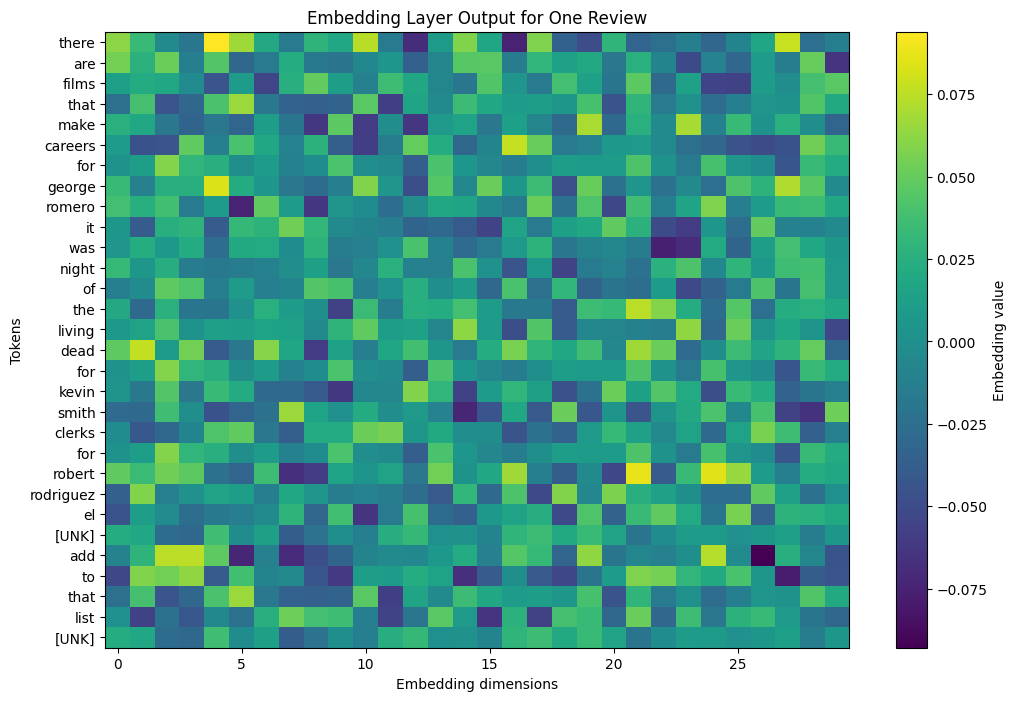

In [88]:
import matplotlib.pyplot as plt

num_tokens_to_show = 30
num_dims_to_show = 30

plt.figure(figsize=(12, 8))

plt.imshow(
    embedding_matrix[:num_tokens_to_show, :num_dims_to_show],
    aspect="auto"
)

plt.colorbar(label="Embedding value")
plt.title("Embedding Layer Output for One Review")
plt.xlabel("Embedding dimensions")
plt.ylabel("Tokens")

plt.yticks(
    ticks=range(num_tokens_to_show),
    labels=tokens[:num_tokens_to_show]
)

plt.show()

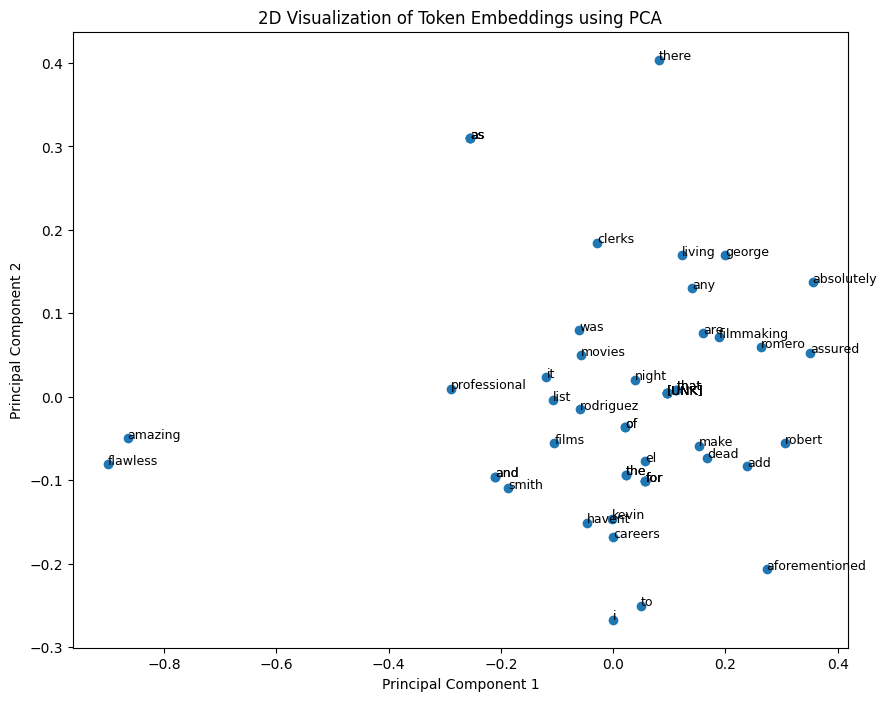

In [89]:
from sklearn.decomposition import PCA

# Supprimer les tokens de padding
non_padding_indices = [
    i for i, token in enumerate(tokens)
    if token != ""
]

tokens_no_padding = [tokens[i] for i in non_padding_indices]
embeddings_no_padding = embedding_matrix[non_padding_indices]

# Limiter aux 50 premiers tokens non-padding
tokens_to_plot = tokens_no_padding[:50]
embeddings_to_plot = embeddings_no_padding[:50]

pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings_to_plot)

plt.figure(figsize=(10, 8))

plt.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1]
)

for i, token in enumerate(tokens_to_plot):
    plt.annotate(
        token,
        (embeddings_2d[i, 0], embeddings_2d[i, 1]),
        fontsize=9
    )

plt.title("2D Visualization of Token Embeddings using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

To better understand how the BiLSTM model processes text, we visualized the output of the Embedding layer for one sample review. First, the selected review was converted into a sequence of integer token IDs using the `TextVectorization` layer. Then, these token IDs were passed through the Embedding layer, which transformed each token into a dense vector representation. Since each token is represented by a 128-dimensional vector, the embedding output for one review is a matrix of shape `(sequence_length, embedding_dim)`. We visualized part of this matrix as a heatmap, where each row corresponds to a token and each column corresponds to an embedding dimension. To provide a more intuitive view, we also applied PCA to reduce the token embeddings from 128 dimensions to 2 dimensions and plotted them in a 2D space. This visualization helps illustrate how words from the review are represented numerically before being processed by the BiLSTM layer.

# **Step 5 bis — improved BiLSTM**

In [90]:
MAX_TOKENS = 30000
SEQUENCE_LENGTH = 500
EMBEDDING_DIM = 128

In [91]:
vectorizer_improved = TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode="int",
    output_sequence_length=SEQUENCE_LENGTH
)

vectorizer_improved.adapt(train_texts_array)

In [92]:
bilstm_improved_model = models.Sequential([
    layers.Input(shape=(), dtype=tf.string),
    vectorizer_improved,
    layers.Embedding(
        input_dim=MAX_TOKENS,
        output_dim=EMBEDDING_DIM,
        mask_zero=True
    ),
    layers.Bidirectional(layers.LSTM(64, dropout=0.2)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

bilstm_improved_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_1            │ (None, 500)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 500, 128)       │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,947,137 (15.06 MB)

 Trainable params: 3,947,137 (15.06 MB)

 Non-trainable params: 0 (0.00 B)

In [93]:
bilstm_improved_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [94]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# Create TensorFlow Datasets for improved BiLSTM model
train_dataset_bilstm_improved = tf.data.Dataset.from_tensor_slices((train_texts_array, train_labels_array)).batch(BATCH_SIZE_FIT).prefetch(tf.data.AUTOTUNE)
validation_dataset_bilstm_improved = tf.data.Dataset.from_tensor_slices((val_texts_array, val_labels_array)).batch(BATCH_SIZE_FIT).prefetch(tf.data.AUTOTUNE)

history_bilstm_improved = bilstm_improved_model.fit(
    train_dataset_bilstm_improved,
    validation_data=validation_dataset_bilstm_improved,
    epochs=20,
    callbacks=[early_stopping]
)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 15s 52ms/step - accuracy: 0.5621 - loss: 0.6900 - val_accuracy: 0.7107 - val_loss: 0.6601
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step - accuracy: 0.8078 - loss: 0.4582 - val_accuracy: 0.8252 - val_loss: 0.3875
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 12s 53ms/step - accuracy: 0.8984 - loss: 0.2771 - val_accuracy: 0.8684 - val_loss: 0.3341
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step - accuracy: 0.9350 - loss: 0.1924 - val_accuracy: 0.8785 - val_loss: 0.3079
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 12s 53ms/step - accuracy: 0.9517 - loss: 0.1426 - val_accuracy: 0.8833 - val_loss: 0.3212
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - accuracy: 0.9657 - loss: 0.1079 - val_accuracy: 0.8729 - val_loss: 0.3538
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - accuracy: 0.9763 - loss: 0.0800 - val_accuracy: 0.8756 - val_loss: 0.3903


In [96]:
test_dataset_bilstm_improved = tf.data.Dataset.from_tensor_slices((test_texts_array, test_labels_array)).batch(BATCH_SIZE_FIT).prefetch(tf.data.AUTOTUNE)

bilstm_improved_val_loss, bilstm_improved_val_accuracy = bilstm_improved_model.evaluate(
    validation_dataset_bilstm_improved
)

bilstm_improved_test_loss, bilstm_improved_test_accuracy = bilstm_improved_model.evaluate(
    test_dataset_bilstm_improved
)

print("Validation Accuracy:", bilstm_improved_val_accuracy)
print("Test Accuracy:", bilstm_improved_test_accuracy)

157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.8785 - loss: 0.3079
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.8626 - loss: 0.3375
Validation Accuracy: 0.8784999847412109
Test Accuracy: 0.8626000285148621


In [97]:
results.append({
    "Model": "Improved BiLSTM",
    "Validation Accuracy": bilstm_improved_val_accuracy,
    "Test Accuracy": bilstm_improved_test_accuracy
})

results_df = pd.DataFrame(results)
results_df

,Model,Validation Accuracy,Test Accuracy
0,TF-IDF + Logistic Regression,0.8830,0.87628
1,TensorFlow Hub + Dense,0.8578,0.84560
2,TensorFlow Hub USE + Dense,0.8563,0.85752
3,TensorFlow Hub NNLM 128D + Dense,0.8732,0.85992
4,BiLSTM,0.8568,0.84264
5,Improved BiLSTM,0.8785,0.86260


The improved BiLSTM model performed better than the initial BiLSTM architecture, mainly due to a longer input sequence, a larger vocabulary, a lower learning rate, and more moderate dropout.

However, the BiLSTM still underperformed compared to the TF-IDF + Logistic Regression baseline.  
This suggests that, for this dataset and training setup, the sequential deep learning model does not provide a clear advantage over the classical baseline.

The TF-IDF model remains the best-performing approach so far.

# **Step 6 — DistilBERT with Hugging Face**

The final model used in this project is `distilbert-base-uncased`, a lighter and faster version of BERT obtained through knowledge distillation. DistilBERT keeps the main Transformer-based architecture of BERT but reduces the number of Transformer encoder layers, making it more efficient while preserving strong language understanding capabilities. In this experiment, each IMDB review was first tokenized using the DistilBERT tokenizer. The tokenizer converts raw text into subword tokens, then maps these tokens to numerical IDs that can be processed by the model. Reviews were truncated to a maximum length of 256 tokens to control memory usage and training time. The tokenized inputs were then passed to `AutoModelForSequenceClassification`, which adds a classification head on top of the pre-trained DistilBERT encoder. During fine-tuning, the model updates its weights using the IMDB training data so that the learned language representations become adapted to the binary sentiment classification task. The final classification layer outputs two scores corresponding to the negative and positive classes, and the class with the highest score is selected as the prediction. Compared to the previous models, DistilBERT benefits from contextual word representations: the meaning of each word is interpreted according to the surrounding words in the sentence. This allows the model to better handle complex linguistic patterns, negation, and context-dependent sentiment expressions.

In [98]:
!pip install -q transformers datasets evaluate accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.7 MB/s eta 0:00:00


In [99]:
import torch
import numpy as np
import pandas as pd

from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [100]:
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

GPU available: True
GPU: NVIDIA A100-SXM4-40GB


In [101]:
train_hf = Dataset.from_dict({
    "text": train_texts,
    "label": train_labels
})

val_hf = Dataset.from_dict({
    "text": val_texts,
    "label": val_labels
})

test_hf = Dataset.from_dict({
    "text": test_texts,
    "label": test_labels
})

In [102]:
model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [103]:
def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=256
    )

In [104]:
train_encoded = train_hf.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"]
)

val_encoded = val_hf.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"]
)

test_encoded = test_hf.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"]
)

Map:   0%|          | 0/15000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

#### DistilBERT Tokenization Output

After tokenization, each review is converted into a dictionary containing four elements: `label`, `input_ids`, `token_type_ids`, and `attention_mask`. The `label` corresponds to the target sentiment class, where 0 represents a negative review and 1 represents a positive review. The `input_ids` are the numerical IDs assigned to the tokens produced by the DistilBERT tokenizer. These IDs represent the tokenized version of the original review and are the main input given to the model. The `attention_mask` indicates which tokens should be taken into account by the model: values equal to 1 correspond to real tokens, while values equal to 0 correspond to padding tokens that should be ignored. The `token_type_ids` indicate the segment to which each token belongs. This is mainly useful for tasks involving two input sentences, but in this sentiment classification task each example contains only one review, so the `token_type_ids` are generally filled with zeros. Together, these elements allow DistilBERT to process text inputs in a structured numerical format suitable for Transformer-based classification.

In [121]:
train_encoded

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 15000
})

In [113]:
train_encoded[0]['label']


0

In [118]:
len(train_encoded[0]['input_ids'])


149

In [119]:
len(train_encoded[0]['token_type_ids'])

149

In [120]:
len(train_encoded[0]['attention_mask'])

149

In [122]:
example = train_encoded[0]

print(example["input_ids"][:30])
tokens = tokenizer.convert_ids_to_tokens(example["input_ids"])
print(tokens[:30])

[101, 2023, 2001, 2019, 7078, 6659, 3185, 1012, 2123, 1005, 1056, 2022, 26673, 1999, 2011, 5696, 3328, 2368, 2030, 2745, 3707, 7363, 1012, 2119, 2024, 2307, 5889, 1010, 2021, 2023]
['[CLS]', 'this', 'was', 'an', 'absolutely', 'terrible', 'movie', '.', 'don', "'", 't', 'be', 'lured', 'in', 'by', 'christopher', 'walk', '##en', 'or', 'michael', 'iron', '##side', '.', 'both', 'are', 'great', 'actors', ',', 'but', 'this']


In [141]:
print(tokens[-30:])

['am', 'disappointed', 'that', 'there', 'are', 'movies', 'like', 'this', ',', 'ruining', 'actor', "'", 's', 'like', 'christopher', 'walk', '##en', "'", 's', 'good', 'name', '.', 'i', 'could', 'barely', 'sit', 'through', 'it', '.', '[SEP]']


In [123]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

After tokenization, reviews may have different sequence lengths if fixed padding is not applied. The `max_length` parameter only defines the maximum allowed length, and longer reviews are truncated. Shorter reviews keep their original tokenized length. During training, `DataCollatorWithPadding` dynamically pads the examples within each batch so that all sequences in the same batch have the same length. Padding tokens are ignored by the model using the `attention_mask`.

In [124]:
distilbert_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [125]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary"
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [126]:
training_args = TrainingArguments(
    output_dir="./distilbert-imdb-results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=20,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_dir="./logs",
    logging_steps=100,
    report_to="none"
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [127]:
# Reinstall torch and torchvision to resolve potential import issues
#!pip uninstall -y torch torchvision torchaudio
#!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

trainer = Trainer(
    model=distilbert_model,
    args=training_args,
    train_dataset=train_encoded,
    eval_dataset=val_encoded,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.278004,0.251194,0.899500,0.895048,0.905589,0.900288
2,0.173771,0.308992,0.897000,0.872659,0.930140,0.900483
3,0.114373,0.377335,0.902000,0.899643,0.905389,0.902507
4,0.068155,0.454602,0.901800,0.896613,0.908782,0.902657
5,0.039080,0.585747,0.896800,0.925728,0.863273,0.893410
6,0.030401,0.625770,0.900300,0.882701,0.923752,0.902760
7,0.040537,0.576170,0.900600,0.899522,0.902395,0.900957
8,0.032707,0.679009,0.901600,0.891482,0.914970,0.903073
9,0.014027,0.758876,0.900800,0.906351,0.894411,0.900342
10,0.005682,0.858679,0.897400,0.876987,0.924950,0.900330


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=18760, training_loss=0.04421539496922198, metrics={'train_runtime': 1979.3768, 'train_samples_per_second': 151.563, 'train_steps_per_second': 9.478, 'total_flos': 1.98701097984e+16, 'train_loss': 0.04421539496922198, 'epoch': 20.0})

## DistilBERT Pipeline: From Tokenization to Sentiment Classification

The DistilBERT model processes each IMDB review through several steps, starting from raw text and ending with a sentiment prediction.

First, the raw review is passed to the DistilBERT tokenizer. The tokenizer splits the text into tokens or subword units, adds special tokens such as `[CLS]` at the beginning and `[SEP]` at the end, and converts each token into a numerical ID. The output of this step contains four main elements: `label`, `input_ids`, `token_type_ids`, and `attention_mask`.

Long reviews are truncated to a maximum length of 256 tokens using `truncation=True` and `max_length=256`. Since dynamic padding is used with `DataCollatorWithPadding`, reviews can initially have different tokenized lengths. Padding is added only when batches are created, so all reviews inside the same batch have the same length. This is more efficient than padding all reviews to the same fixed length.

After tokenization, the `input_ids` are passed to the embedding layer inside DistilBERT. At this stage, each token ID is converted into a dense vector of 768 dimensions. DistilBERT combines token embeddings with positional embeddings. Token embeddings represent the identity and meaning of each token, while positional embeddings provide information about the position of each token in the sequence. These two embeddings are added together, not concatenated, so each of the 768 dimensions contains both lexical and positional information.

The resulting embeddings are then passed through the Transformer encoder layers of DistilBERT. These layers use self-attention, which allows each token to interact with the other tokens in the review. This helps the model understand context, negation, and complex sentiment expressions. For example, in a sentence such as “The movie was not good”, the model can learn that the word “not” changes the meaning of “good”.

Finally, a classification head is added on top of DistilBERT. This head takes the contextual representation produced by the Transformer and outputs two scores: one for the negative class and one for the positive class. The class with the highest score is selected as the final prediction.

Overall, the pipeline can be summarized as:

**Raw review → Tokenization → input_ids and attention_mask → Dynamic padding → DistilBERT embeddings → Transformer encoder layers → Classification head → Sentiment prediction**

In [130]:
distilbert_val_results = trainer.evaluate(val_encoded)
distilbert_test_results = trainer.evaluate(test_encoded)

print("Validation results:")
print(distilbert_val_results)

print("\nTest results:")
print(distilbert_test_results)

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.000041,0.955809,20,0.906200,0.906225,0.906587,0.906406


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.000041,0.948049,20,0.907640,0.907086,0.908320,0.907703


Validation results:
{'eval_loss': 0.9558085203170776, 'eval_accuracy': 0.9062, 'eval_precision': 0.9062250598563448, 'eval_recall': 0.9065868263473054, 'eval_f1': 0.9064059070045899}

Test results:
{'eval_loss': 0.9480493068695068, 'eval_accuracy': 0.90764, 'eval_precision': 0.9070863625469362, 'eval_recall': 0.90832, 'eval_f1': 0.9077027621217572}


In [131]:
distilbert_val_accuracy = distilbert_val_results["eval_accuracy"]
distilbert_test_accuracy = distilbert_test_results["eval_accuracy"]

print("Validation Accuracy:", distilbert_val_accuracy)
print("Test Accuracy:", distilbert_test_accuracy)

Validation Accuracy: 0.9062
Test Accuracy: 0.90764


In [132]:
results.append({
    "Model": "DistilBERT",
    "Validation Accuracy": distilbert_val_accuracy,
    "Test Accuracy": distilbert_test_accuracy
})

results_df = pd.DataFrame(results)
results_df

,Model,Validation Accuracy,Test Accuracy
0,TF-IDF + Logistic Regression,0.8830,0.87628
1,TensorFlow Hub + Dense,0.8578,0.84560
2,TensorFlow Hub USE + Dense,0.8563,0.85752
3,TensorFlow Hub NNLM 128D + Dense,0.8732,0.85992
4,BiLSTM,0.8568,0.84264
5,Improved BiLSTM,0.8785,0.86260
6,DistilBERT,0.9062,0.90764


In [133]:
distilbert_predictions_output = trainer.predict(test_encoded)

distilbert_logits = distilbert_predictions_output.predictions
distilbert_predictions = np.argmax(distilbert_logits, axis=-1)

In [134]:
print(classification_report(
    test_labels,
    distilbert_predictions,
    target_names=["Negative", "Positive"]
))

              precision    recall  f1-score   support

    Negative       0.91      0.91      0.91     12500
    Positive       0.91      0.91      0.91     12500

    accuracy                           0.91     25000
   macro avg       0.91      0.91      0.91     25000
weighted avg       0.91      0.91      0.91     25000



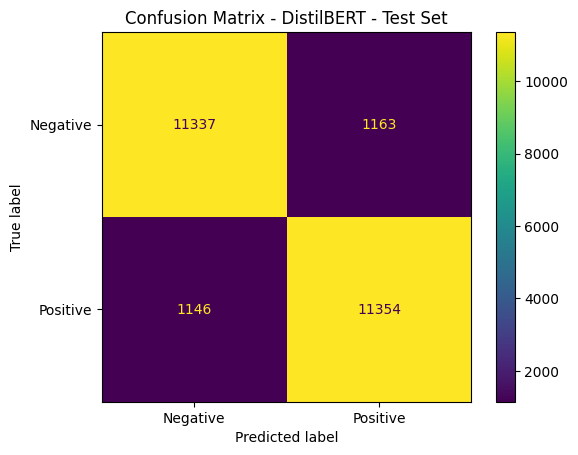

In [135]:
cm_distilbert = confusion_matrix(test_labels, distilbert_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_distilbert,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("Confusion Matrix - DistilBERT - Test Set")
plt.show()

## Final Model Comparison

DistilBERT achieved the best performance among all evaluated models, with a validation accuracy of 90.62% and a test accuracy of 90.76%.

Compared to the strongest classical baseline, TF-IDF + Logistic Regression, DistilBERT improved test accuracy by approximately 3 percentage points.

This confirms the benefit of using a pre-trained Transformer model for sentiment classification, especially when fine-tuned directly on the target dataset.

In [137]:
results_df_sorted = results_df.sort_values(
    by="Test Accuracy",
    ascending=False
)

results_df_sorted

,Model,Validation Accuracy,Test Accuracy
6,DistilBERT,0.9062,0.90764
0,TF-IDF + Logistic Regression,0.8830,0.87628
5,Improved BiLSTM,0.8785,0.86260
3,TensorFlow Hub NNLM 128D + Dense,0.8732,0.85992
2,TensorFlow Hub USE + Dense,0.8563,0.85752
1,TensorFlow Hub + Dense,0.8578,0.84560
4,BiLSTM,0.8568,0.84264


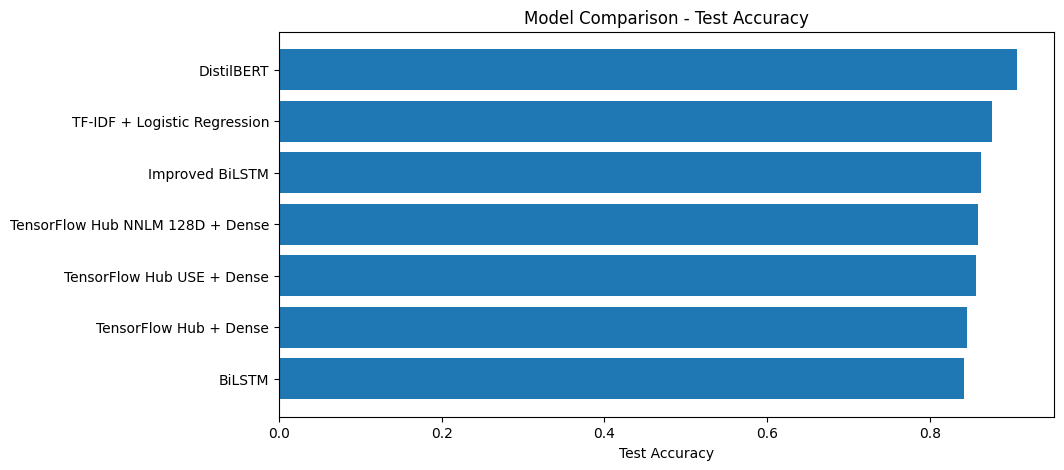

In [138]:

plt.figure(figsize=(10, 5))

plt.barh(
    results_df_sorted["Model"],
    results_df_sorted["Test Accuracy"]
)

plt.xlabel("Test Accuracy")
plt.title("Model Comparison - Test Accuracy")
plt.gca().invert_yaxis()
plt.show()

In [139]:
error_df = pd.DataFrame({
    "review": test_texts,
    "true_label": test_labels,
    "predicted_label": distilbert_predictions
})

error_df["true_sentiment"] = error_df["true_label"].map({
    0: "Negative",
    1: "Positive"
})

error_df["predicted_sentiment"] = error_df["predicted_label"].map({
    0: "Negative",
    1: "Positive"
})

misclassified_df = error_df[
    error_df["true_label"] != error_df["predicted_label"]
]

print("Number of misclassified reviews:", len(misclassified_df))
misclassified_df.head()

Number of misclassified reviews: 2309


,review,true_label,predicted_label,true_sentiment,predicted_sentiment
13,I saw this movie as part of a Billy Graham pro...,0,1,Negative,Positive
16,I own a Video store with hundreds of documenta...,1,0,Positive,Negative
21,This classic has so many great one-liners and ...,1,0,Positive,Negative
38,Just saw this film at the Fantasy Filmfest BER...,0,1,Negative,Positive
40,This game is not exactly the best N64 game eve...,1,0,Positive,Negative


In [140]:
for i, row in misclassified_df.head(5).iterrows():
    print("True label:", row["true_sentiment"])
    print("Predicted label:", row["predicted_sentiment"])
    print("Review:")
    print(row["review"][:1000])
    print("-" * 100)

True label: Negative
Predicted label: Positive
Review:
I saw this movie as part of a Billy Graham program. The church I attend was part of a community wide outreach to present God and Christianity to our community (Hartford, Ct. USA). I was one of the counselors who helped attendees (who were invited to come forward and make whatever kind of religious profession they wanted...and to follow up on them after the movie. As such, it did what it was supposed to do, and I personally found it to be a medium to strengthen my faith in God.I also found it to be very helpful to those I counseled. I especially like the work of Kim Darby in this movie. And the parents (the Wintons?) were , in a way, a little overdrawn....no one says to their child if they think that he or she may be the parent of an illegitimate child something like the Wintons did "oh, no, no, not thaaat." That isn't exactly what they said, but the sympaathetic audience I saw had a laugh at whatever it was they did say, and also a

## Conclusion

This project compared several approaches for binary sentiment classification on the IMDB Reviews dataset.

The evaluated models included classical machine learning, TensorFlow Hub embeddings, recurrent neural networks, and a Transformer-based model.

The TF-IDF + Logistic Regression baseline achieved strong results, outperforming several deep learning architectures. However, the fine-tuned DistilBERT model achieved the best overall performance, reaching 90.76% test accuracy.

This demonstrates that while classical NLP methods remain highly competitive, Transformer-based models can provide superior performance when fine-tuned on the target task.